# Exploratory Data Analysis on HIV Dataset

In [1]:
%load_ext watermark
%watermark -v -p DeepChem,numpy,mlflow,pandas,matplotlib,seaborn,scipy,sklearn,streamlit,torch,torch-geometric,rdkit

Python implementation: CPython
Python version       : 3.14.7
IPython version      : 9.17.1

DeepChem       : 2.5.0
numpy          : 2.5.3
mlflow         : 3.16.1
pandas         : 3.0.6
matplotlib     : 3.11.2
seaborn        : 0.13.2
scipy          : 1.18.1
sklearn        : 1.9.1
streamlit      : 1.65.0
torch          : 2.14.1
torch-geometric: 2.8.0.post1
rdkit          : 2026.3.6



In [2]:
import deepchem as dc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import Draw

Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead


## Load dataset

In [3]:
hiv_df = pd.read_csv('../data/HIV.csv')
hiv_df.head()

,smiles,activity,HIV_active
0,CCC1=[O+][Cu-3]2([O+]=C(CC)C1)[O+]=C(CC)CC(CC)...,CI,0
1,C(=Cc1ccccc1)C1=[O+][Cu-3]2([O+]=C(C=Cc3ccccc3...,CI,0
2,CC(=O)N1c2ccccc2Sc2c1ccc1ccccc21,CI,0
3,Nc1ccc(C=Cc2ccc(N)cc2S(=O)(=O)O)c(S(=O)(=O)O)c1,CI,0
4,O=S(=O)(O)CCS(=O)(=O)O,CI,0


## Statistics

In [4]:
hiv_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41127 entries, 0 to 41126
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   smiles      41127 non-null  str  
 1   activity    41127 non-null  str  
 2   HIV_active  41127 non-null  int64
dtypes: int64(1), str(2)
memory usage: 2.8 MB


In [5]:
print("Number of molecules:", hiv_df.shape[0])

Number of molecules: 41127


In [6]:
hiv_df['activity'].value_counts()

activity
CI    39684
CM     1039
CA      404
Name: count, dtype: int64

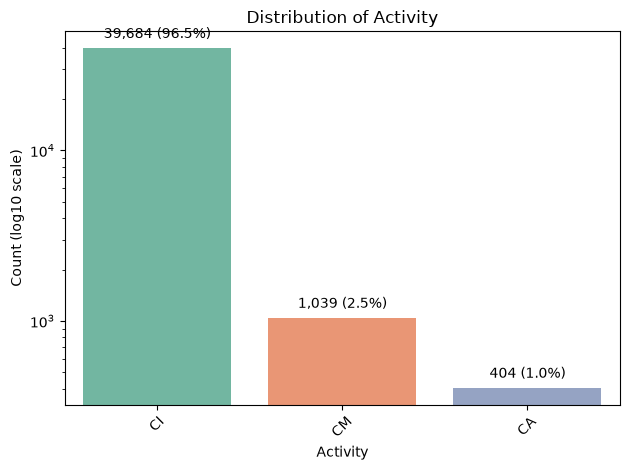

In [7]:
ax = sns.countplot(
    x="activity",
    data=hiv_df,
    hue="activity",
    palette="Set2",
    legend=False
)

total = len(hiv_df)

# Add count + percentage above each bar
for container in ax.containers:
    for bar in container:
        count = int(bar.get_height())
        percentage = 100 * count / total
        
        ax.annotate(
            f"{count:,} ({percentage:.1f}%)",
            (bar.get_x() + bar.get_width() / 2, bar.get_height()),
            ha="center",
            va="bottom",
            xytext=(0, 5),
            textcoords="offset points"
        )

ax.set_xlabel("Activity")
ax.set_ylabel("Count (log10 scale)")
ax.set_title("Distribution of Activity")

plt.yscale("log")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [8]:
hiv_df['HIV_active'].value_counts()

HIV_active
0    39684
1     1443
Name: count, dtype: int64

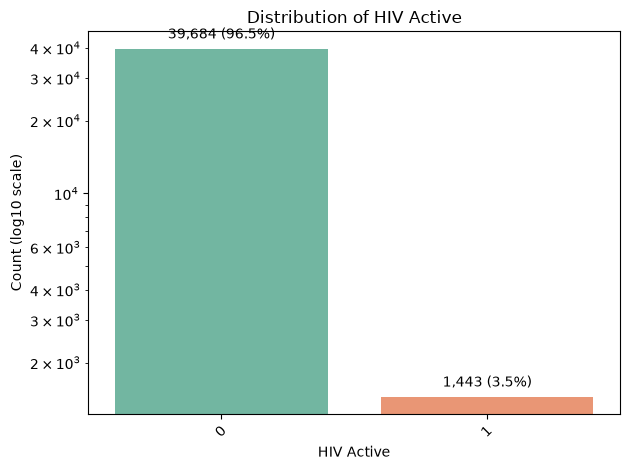

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.countplot(
    x="HIV_active",
    data=hiv_df,
    hue="HIV_active",
    palette="Set2",
    legend=False
)

total = len(hiv_df)

# Add count + percentage above each bar
for container in ax.containers:
    for bar in container:
        count = int(bar.get_height())
        percentage = 100 * count / total
        
        ax.annotate(
            f"{count:,} ({percentage:.1f}%)",
            (bar.get_x() + bar.get_width() / 2, bar.get_height()),
            ha="center",
            va="bottom",
            xytext=(0, 5),
            textcoords="offset points"
        )

ax.set_xlabel("HIV Active")
ax.set_ylabel("Count (log10 scale)")
ax.set_title("Distribution of HIV Active")

plt.yscale("log")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Visualize molecules

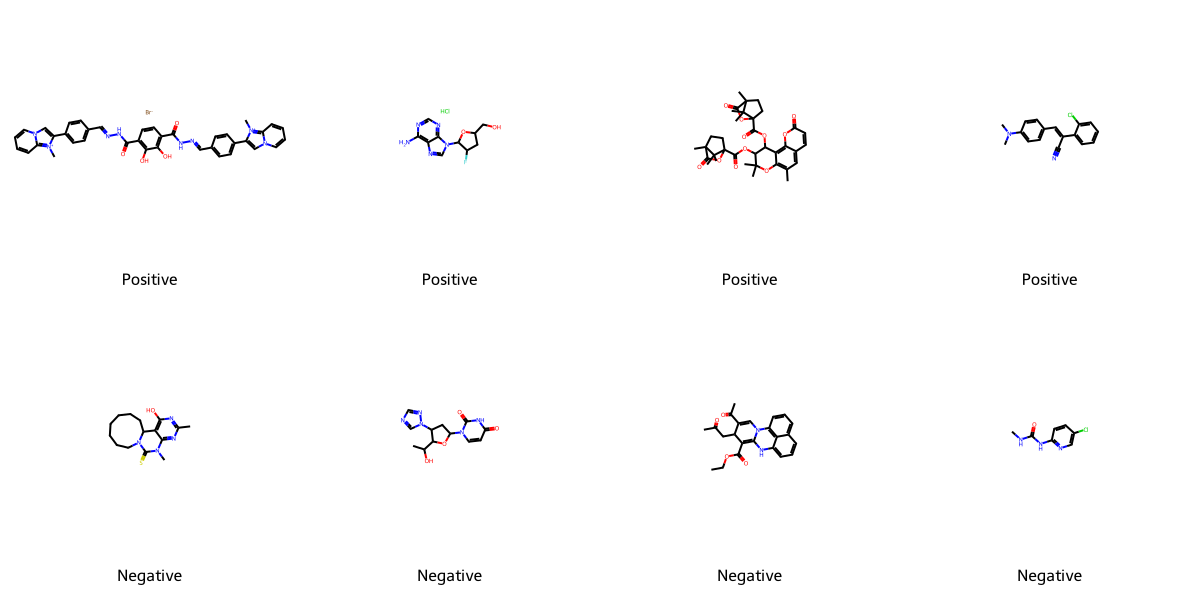

In [10]:
from rdkit import Chem
from rdkit.Chem import Draw

# Get 4 positive and 4 negative molecules
positive = hiv_df[hiv_df["HIV_active"] == 1].sample(4)
negative = hiv_df[hiv_df["HIV_active"] == 0].sample(4)

selected = pd.concat([positive, negative])

# Convert SMILES to RDKit molecules
mols = [Chem.MolFromSmiles(s) for s in selected["smiles"]]

# Add class labels
legends = [
    "Positive" if activity == 1 else "Negative"
    for activity in selected["HIV_active"]
]

Draw.MolsToGridImage(
    mols,
    molsPerRow=4,
    subImgSize=(300, 300),
    legends=legends
)

## DeepChem Featurizer

In [15]:
featurizer = dc.feat.MolGraphConvFeaturizer(use_edges=True, use_chirality=True, use_partial_charge=True)
mol_features = featurizer(mols)

In [16]:
mol_features[0].num_node_features

33

In [17]:
mol_features[0].num_edge_features

11

## Save data

In [ ]:
final_hiv_df = hiv_df[['smiles', 'HIV_active']].copy()
final_hiv_df.to_csv('../data/raw/HIV.csv', index=False)